In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/drive/MyDrive/PracticeDA/updated_file_with_temperature_difference.csv')

In [ ]:
#Data preprocessing: Label Encoding

from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('/content/drive/MyDrive/PracticeDA/ai4i2020.csv')


label_encoder = LabelEncoder()

df['Type'] = label_encoder.fit_transform(df['Type'])

print("\nDataset after Label Encoding:")
print(df.head())

df.to_csv('updated_file.csv', index=False)
print("\nUpdated dataset saved to 'updated_file.csv'.")


Dataset after Label Encoding:
   UDI Product ID  Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860     2                298.1                    308.6   
1    2     L47181     1                298.2                    308.7   
2    3     L47182     1                298.1                    308.5   
3    4     L47183     1                298.2                    308.6   
4    5     L47184     1                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0   

In [ ]:
#Normalization using Min-Max Scaling

from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('/content/drive/MyDrive/PracticeDA/updated_file.csv')

numerical_features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

scaler = MinMaxScaler()

df[numerical_features] = scaler.fit_transform(df[numerical_features])

df.to_csv('normalized_file.csv', index=False)

In [ ]:
#Feature Engineering: Temperature Difference

df = pd.read_csv('/content/drive/MyDrive/PracticeDA/normalized_file.csv')

df['Temperature Difference [k]'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['Any Failure'] = df[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']].max(axis=1)

# Display the updated dataset
print("Dataset with Temperature Difference:")
print(df.head())

# Save the updated dataset to a new CSV file (optional)
df.to_csv('updated_file_with_temperature_difference.csv', index=False)
print("\nUpdated dataset saved to 'updated_file_with_temperature_difference.csv'.")

Dataset with Temperature Difference:
   UDI Product ID  Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860     2             0.304348                 0.358025   
1    2     L47181     1             0.315217                 0.370370   
2    3     L47182     1             0.304348                 0.345679   
3    4     L47183     1             0.315217                 0.358025   
4    5     L47184     1             0.315217                 0.370370   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                0.222934     0.535714         0.000000                0    0   
1                0.139697     0.583791         0.011858                0    0   
2                0.192084     0.626374         0.019763                0    0   
3                0.154249     0.490385         0.027668                0    0   
4                0.139697     0.497253         0.035573                0    0   

   HDF  PWF  OSF  RNF  Temperature Di

In [ ]:
from sklearn.model_selection import train_test_split
df = pd.read_csv('/content/drive/MyDrive/PracticeDA/updated_file_with_temperature_difference.csv')
# Features (X) and target (y)
X = df.drop(columns=['UDI', 'Product ID', 'Machine failure', 'Any Failure'])
y = df['Machine failure']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (8000, 12)
Testing set shape: (2000, 12)


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/PracticeDA/updated_file_with_temperature_difference.csv')

# Features (X) and target (y)
# Drop the target column and any irrelevant columns (e.g., UDI, Product ID)
X = df.drop(columns=['UDI', 'Product ID', 'Machine failure', 'Any Failure'])  # Pass column names as a list
y = df['Machine failure']

# Display the features (X) and target (y)
print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0     2             0.304348                 0.358025                0.222934   
1     1             0.315217                 0.370370                0.139697   
2     1             0.304348                 0.345679                0.192084   
3     1             0.315217                 0.358025                0.154249   
4     1             0.315217                 0.370370                0.139697   

   Torque [Nm]  Tool wear [min]  TWF  HDF  PWF  OSF  RNF  \
0     0.535714         0.000000    0    0    0    0    0   
1     0.583791         0.011858    0    0    0    0    0   
2     0.626374         0.019763    0    0    0    0    0   
3     0.490385         0.027668    0    0    0    0    0   
4     0.497253         0.035573    0    0    0    0    0   

   Temperature Difference [k]  
0                    0.053677  
1                    0.055153  
2                    0.041331  
3         

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize the model
log_reg = LogisticRegression(random_state=42)

# Train the model
log_reg.fit(X_train, y_train)

# Make predictions
y_pred = log_reg.predict(X_test)

# Evaluate the model
print("Logistic Regression Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

Logistic Regression Metrics:
Accuracy: 0.999
Precision: 1.0
Recall: 0.9672131147540983
F1-Score: 0.9833333333333333
ROC-AUC: 0.9836065573770492


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the model
dt = DecisionTreeClassifier(random_state=42)

# Train the model
dt.fit(X_train, y_train)

# Make predictions
y_pred = dt.predict(X_test)

# Evaluate the model
print("Decision Tree Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

Decision Tree Metrics:
Accuracy: 0.997
Precision: 0.9365079365079365
Recall: 0.9672131147540983
F1-Score: 0.9516129032258065
ROC-AUC: 0.9825750978618351


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
rf = RandomForestClassifier(random_state=42)

# Train the model
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)

# Evaluate the model
print("Random Forest Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

Random Forest Metrics:
Accuracy: 0.999
Precision: 1.0
Recall: 0.9672131147540983
F1-Score: 0.9833333333333333
ROC-AUC: 0.9836065573770492


<ipython-input-16-56632df48520>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_counts.index, y=failure_counts.values, palette='viridis')


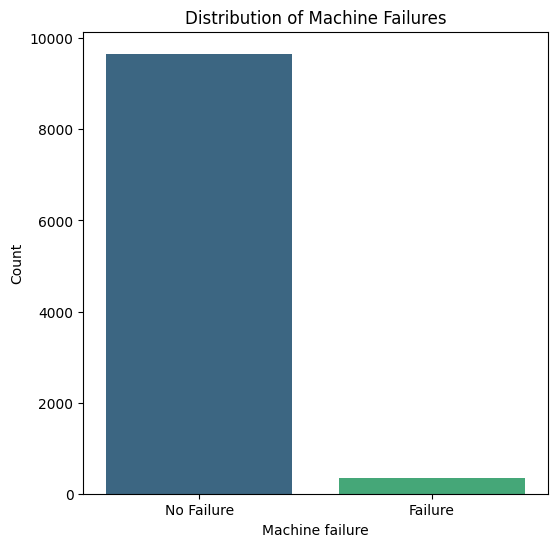

In [ ]:
# Count the number of failures and non-failures
failure_counts = df['Machine failure'].value_counts()

# Plot the distribution
plt.figure(figsize=(6, 6))
sns.barplot(x=failure_counts.index, y=failure_counts.values, palette='viridis')
plt.title('Distribution of Machine Failures')
plt.xlabel('Machine failure')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Failure', 'Failure'])
plt.show()

<ipython-input-17-31992473d89f>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_types.index, y=failure_types.values, palette='magma')


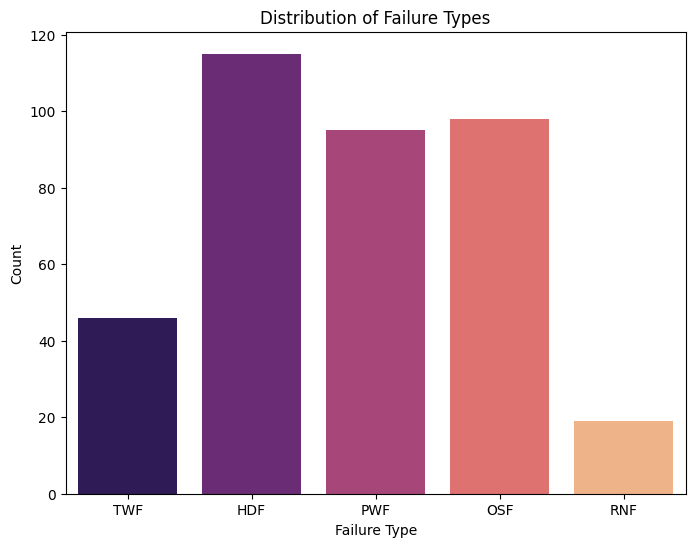

In [ ]:
# Count the occurrences of each failure type
failure_types = df[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']].sum()

# Plot the distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=failure_types.index, y=failure_types.values, palette='magma')
plt.title('Distribution of Failure Types')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.show()

<ipython-input-18-98baaa0e6c81>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='plasma')


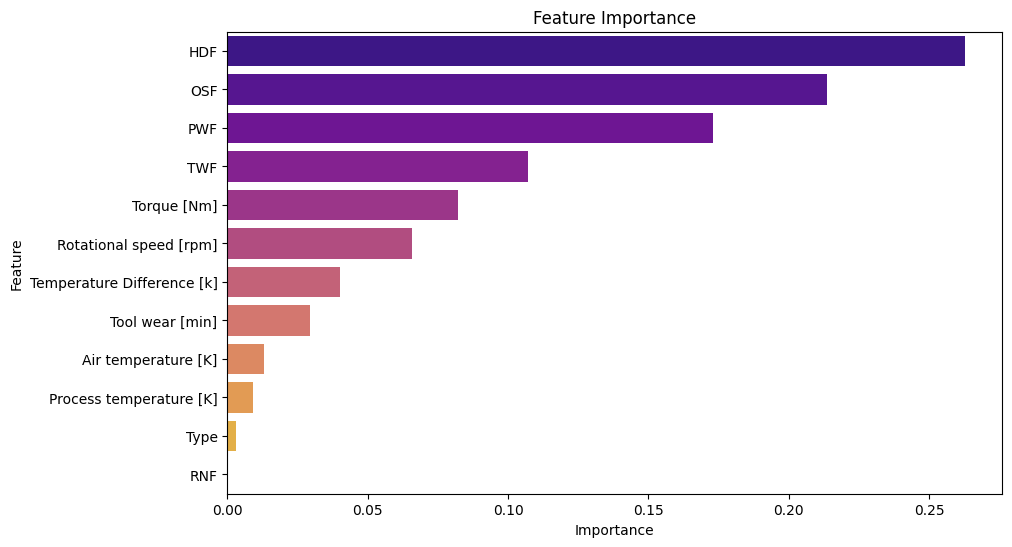

In [ ]:
# Get feature importances from the Random Forest model
importances = rf.feature_importances_
feature_names = X.columns

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='plasma')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

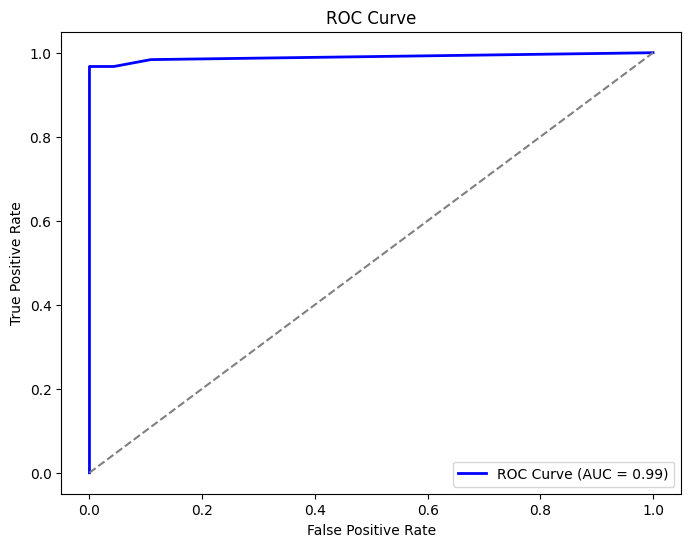

In [ ]:
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the positive class
y_pred_prob = rf.predict_proba(X_test)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Calculate AUC
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()